# Supply Chain Optimization with Pyomo

**DeepBullwhip v0.3.0 Tutorial**

This notebook covers supply chain optimization using DeepBullwhip's Pyomo integration. We'll walk through three progressively complex optimization problems:

1. **Policy parameter tuning** (no solver needed) -- find optimal service levels and smoothing factors via simulation
2. **Inventory optimization** (requires Pyomo + solver) -- find optimal base-stock levels using stochastic programming
3. **Network design** (requires Pyomo + solver) -- decide which facilities to open using mixed-integer programming

### Prerequisites

```bash
# Policy tuning works out of the box (no extra dependencies)
pip install deepbullwhip

# For inventory and network design optimization:
pip install deepbullwhip[optimize]  # installs pyomo
# Plus a solver (choose one):
conda install -c conda-forge glpk   # open-source LP/MIP solver
# or: pip install gurobipy           # commercial (free academic license)
```

---

In [1]:
# --- Colab / Environment Setup ---
# Run this cell first if using Google Colab or a fresh environment.
import importlib, sys

if "google.colab" in sys.modules:
    print("Running on Google Colab -- installing deepbullwhip with extras...")
    get_ipython().system('pip install -q "deepbullwhip[network,viz,optimize]"')
    get_ipython().system('apt-get install -yq glpk-utils > /dev/null 2>&1')
    print("GLPK solver installed.")
elif importlib.util.find_spec("deepbullwhip") is None:
    print("deepbullwhip not found -- installing from local source...")
    get_ipython().system('pip install -q -e "..[network,viz,optimize]"')
else:
    print(f"deepbullwhip ready (v={__import__('deepbullwhip').__version__})")

deepbullwhip ready (v=0.3.0)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from deepbullwhip import (
    EchelonConfig, EdgeConfig, SupplyChainGraph, from_serial,
    NetworkSupplyChain, render_graph,
)
from deepbullwhip.chain.config import beer_game_config, consumer_2tier_config

## 1. Problem Setup: The Cost-Bullwhip Tradeoff

Before optimizing, let's understand the tradeoff. In supply chain management, **service level** (the probability of not stocking out) is the primary policy parameter. Higher service levels mean more safety stock, which:
- **Reduces** stockout costs (backorder penalties)
- **Increases** holding costs (carrying excess inventory)
- **Amplifies** the bullwhip effect (over-ordering cascades upstream)

The key question: **what service level balances these competing objectives?**

Let's set up a simple experiment to visualize this tradeoff:

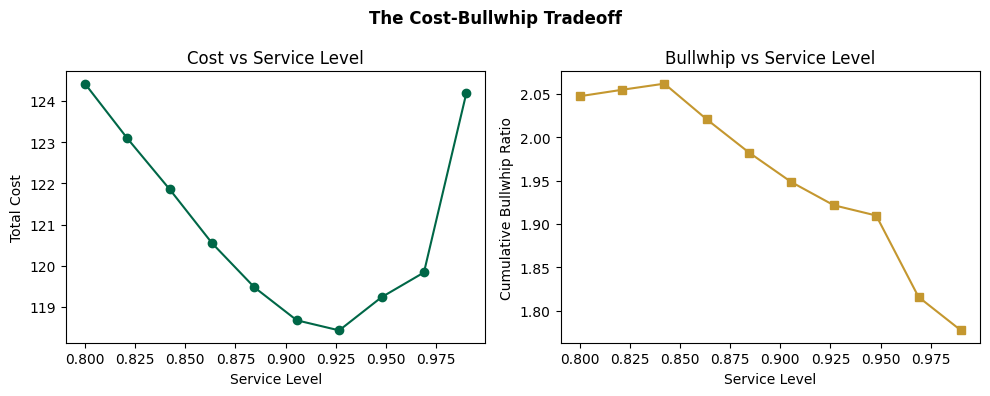

Observation: Higher service levels reduce cost (fewer stockouts)
but can amplify the bullwhip effect (more aggressive ordering).


In [3]:
# Setup: 2-tier consumer goods chain with stochastic demand
graph = from_serial(consumer_2tier_config())
T = 52  # one year of weekly data
rng = np.random.default_rng(42)
demand = np.maximum(rng.normal(loc=10.0, scale=2.0, size=T), 0)

# Sweep service levels from 0.80 to 0.99 and measure cost + bullwhip
from deepbullwhip.policy.order_up_to import OrderUpToPolicy

service_levels = np.linspace(0.80, 0.99, 10)
costs, bullwhips = [], []

for sl in service_levels:
    policies = {
        name: OrderUpToPolicy(lead_time=cfg.lead_time, service_level=sl)
        for name, cfg in graph.nodes.items()
    }
    chain = NetworkSupplyChain(graph, policies=policies)
    result = chain.simulate(
        demand={"Retailer": demand},
        forecasts_mean={"Retailer": np.full(T, demand.mean())},
        forecasts_std={"Retailer": np.full(T, demand.std())},
    )
    costs.append(result.total_cost)
    bullwhips.append(result.cumulative_bullwhip)

# Plot the tradeoff
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(service_levels, costs, "o-", color="#006747")
ax1.set_xlabel("Service Level")
ax1.set_ylabel("Total Cost")
ax1.set_title("Cost vs Service Level")

ax2.plot(service_levels, bullwhips, "s-", color="#C4972F")
ax2.set_xlabel("Service Level")
ax2.set_ylabel("Cumulative Bullwhip Ratio")
ax2.set_title("Bullwhip vs Service Level")

fig.suptitle("The Cost-Bullwhip Tradeoff", fontweight="bold")
fig.tight_layout()
plt.show()

print("Observation: Higher service levels reduce cost (fewer stockouts)")
print("but can amplify the bullwhip effect (more aggressive ordering).")

## 2. Automated Policy Tuning (No Solver Needed)

Instead of manually sweeping, use `tune_service_levels` to automatically find the optimal configuration. This function:

1. Generates a grid of candidate service levels for each node
2. For small networks (<=3 nodes): exhaustive search over all combinations
3. For larger networks: coordinate descent (optimize one node at a time)
4. Evaluates each candidate by running simulations across your demand scenarios

**Key insight**: Each node can have a *different* optimal service level! Downstream nodes often benefit from higher service levels (facing uncertain customer demand), while upstream nodes may need lower levels (facing smoother, aggregated orders).

### 2.1 Minimize Total Cost

In [4]:
from deepbullwhip.optimize.policy_tuning import tune_service_levels

# Use multiple demand scenarios for robust optimization
scenarios = np.maximum(rng.normal(loc=10.0, scale=2.0, size=(20, 52)), 0)
print(f"Using {scenarios.shape[0]} demand scenarios, each {scenarios.shape[1]} periods long")

# Optimize: minimize total cost
result_cost = tune_service_levels(
    graph, scenarios,
    objective="total_cost",
    grid_points=5,        # 5 candidate values per node
    bounds=(0.80, 0.99),  # search range
)

print(f"\n{'='*50}")
print(f"OPTIMAL SERVICE LEVELS (minimize cost)")
print(f"{'='*50}")
for name, sl in result_cost.parameters.items():
    print(f"  {name:15s}: {sl:.2f}")
print(f"  Expected cost:    {result_cost.objective_value:.1f}")
print(f"  Evaluations:      {result_cost.n_evaluations}")

Using 20 demand scenarios, each 52 periods long



OPTIMAL SERVICE LEVELS (minimize cost)
  Retailer       : 0.80
  Manufacturer   : 0.94
  Expected cost:    133.8
  Evaluations:      25


### 2.2 Compare Objectives: Cost vs Bullwhip vs Weighted

Different objectives lead to different optimal configurations. Let's compare:

In [5]:
# Compare all three objectives
objectives = {
    "total_cost": "Minimize Cost",
    "bullwhip": "Minimize Bullwhip",
    "weighted": "Minimize Cost + 100*BW",
}

results = {}
for obj_key, obj_label in objectives.items():
    r = tune_service_levels(graph, scenarios, objective=obj_key, grid_points=5)
    results[obj_key] = r
    print(f"{obj_label:25s} → Retailer={r.parameters['Retailer']:.2f}, "
          f"Manufacturer={r.parameters['Manufacturer']:.2f}, "
          f"obj={r.objective_value:.1f}")

print("\nInterpretation:")
print("  - 'total_cost' favors higher service levels (avoids expensive stockouts)")
print("  - 'bullwhip' favors lower service levels (less safety stock = smoother ordering)")
print("  - 'weighted' finds a middle ground between the two")

Minimize Cost             → Retailer=0.80, Manufacturer=0.94, obj=133.8


Minimize Bullwhip         → Retailer=0.80, Manufacturer=0.94, obj=2.0


Minimize Cost + 100*BW    → Retailer=0.80, Manufacturer=0.94, obj=330.0

Interpretation:
  - 'total_cost' favors higher service levels (avoids expensive stockouts)
  - 'bullwhip' favors lower service levels (less safety stock = smoother ordering)
  - 'weighted' finds a middle ground between the two


### 2.3 Smoothing Factor Tuning

Instead of Order-Up-To policy, we can use **Smoothing OUT** (exponential smoothing on order quantities). The `alpha_s` parameter controls how aggressively orders respond to demand changes:

- `alpha_s = 1.0`: full response (equivalent to standard OUT, high bullwhip)
- `alpha_s = 0.1`: heavily smoothed (low bullwhip, but sluggish response to demand shifts)

`tune_smoothing_factors` finds the optimal `alpha_s` for each node:

In [6]:
from deepbullwhip.optimize.policy_tuning import tune_smoothing_factors

result_smooth = tune_smoothing_factors(
    graph, scenarios,
    grid_points=5,
    bounds=(0.1, 1.0),
)

print(f"{'='*50}")
print(f"OPTIMAL SMOOTHING FACTORS (minimize cost)")
print(f"{'='*50}")
for name, alpha in result_smooth.parameters.items():
    interpretation = "aggressive" if alpha > 0.7 else "moderate" if alpha > 0.4 else "conservative"
    print(f"  {name:15s}: alpha_s={alpha:.2f} ({interpretation})")
print(f"  Expected cost:    {result_smooth.objective_value:.1f}")

print("\nInterpretation:")
print("  Lower alpha → more smoothing → less bullwhip, but slower response")
print("  Higher alpha → less smoothing → faster response, but more bullwhip")

OPTIMAL SMOOTHING FACTORS (minimize cost)
  Retailer       : alpha_s=1.00 (aggressive)
  Manufacturer   : alpha_s=1.00 (aggressive)
  Expected cost:    141.7

Interpretation:
  Lower alpha → more smoothing → less bullwhip, but slower response
  Higher alpha → less smoothing → faster response, but more bullwhip


## 3. Inventory Optimization with Pyomo (Requires Solver)

For more rigorous optimization, DeepBullwhip can formulate the inventory problem as a **stochastic linear program** using Pyomo. This finds optimal **base-stock levels** that minimize expected cost subject to service level constraints.

**Mathematical formulation:**

$$\min_{S_i} \frac{1}{N} \sum_{s=1}^{N} \sum_{i} \sum_{t=1}^{T} \left[ h_i \cdot I_{i,t,s}^+ + b_i \cdot I_{i,t,s}^- \right]$$

Subject to: fill rate $\geq \alpha_i$ for each node $i$.

Where:
- $S_i$ = base-stock level for node $i$ (decision variable)
- $I_{i,t,s}^+$ = on-hand inventory (holding cost $h_i$)
- $I_{i,t,s}^-$ = backorder quantity (penalty cost $b_i$)
- $N$ = number of demand scenarios

> **Note**: This section requires `pip install deepbullwhip[optimize]` and a solver (GLPK or CBC). If you don't have a solver installed, the model will build successfully but `solve_model` will raise an error.

In [7]:
try:
    from deepbullwhip.optimize.inventory import build_inventory_model, solve_model

    # Build the optimization model
    # Using fewer scenarios for speed (increase for production)
    small_scenarios = scenarios[:5, :20]  # 5 scenarios x 20 periods

    model = build_inventory_model(
        graph, small_scenarios,
        service_levels={"Retailer": 0.95, "Manufacturer": 0.90},
    )

    print("Pyomo model built successfully!")
    print(f"  Decision variables: S[{', '.join(graph.nodes.keys())}]")
    print(f"  Scenarios: {small_scenarios.shape[0]}")
    print(f"  Periods: {small_scenarios.shape[1]}")
    print(f"  Constraints: service level >= 95% (Retailer), >= 90% (Manufacturer)")

    # Try to solve (requires glpk or cbc)
    try:
        result = solve_model(model, solver="glpk")
        print(f"\nOptimal base-stock levels:")
        for name, level in result.base_stock_levels.items():
            print(f"  {name}: S* = {level:.1f}")
        print(f"Expected cost: {result.expected_cost:.1f}")
        print(f"Solver status: {result.solver_status}")
    except Exception as e:
        print(f"\nSolver not available: {e}")
        print("Install a solver: conda install -c conda-forge glpk")
        print("  (On Colab, the setup cell installs it automatically)")

except ImportError as e:
    print(f"Pyomo not installed: {e}")
    print("Install with: pip install deepbullwhip[optimize]")

Pyomo model built successfully!
  Decision variables: S[Retailer, Manufacturer]
  Scenarios: 5
  Periods: 20
  Constraints: service level >= 95% (Retailer), >= 90% (Manufacturer)



Optimal base-stock levels:
  Retailer: S* = 23.8
  Manufacturer: S* = 53.9
Expected cost: 39.6
Solver status: optimal


## 4. Network Design: Facility Location (Requires Solver)

The most strategic optimization: **which facilities should we build?**

Given a set of *candidate* locations and connections, the network design model decides which facilities to open and how much material flows through each link, minimizing total cost (fixed opening costs + variable transport + holding costs).

This is a **mixed-integer program** (MIP) because the "open/close" decisions are binary.

Network design model built!
  Candidate nodes: ['Factory_East', 'Factory_West', 'Warehouse', 'Store']
  Candidate edges: 3
  Demand: Store needs 100.0 units/period
  Decision: open Factory_East (fast, $1000) or Factory_West (slow, $600)?



OPTIMAL NETWORK:


  Open facilities: ['Factory_West', 'Warehouse', 'Store']
  Total cost: 1048.0
  Active edges: [('Factory_West', 'Warehouse'), ('Warehouse', 'Store')]


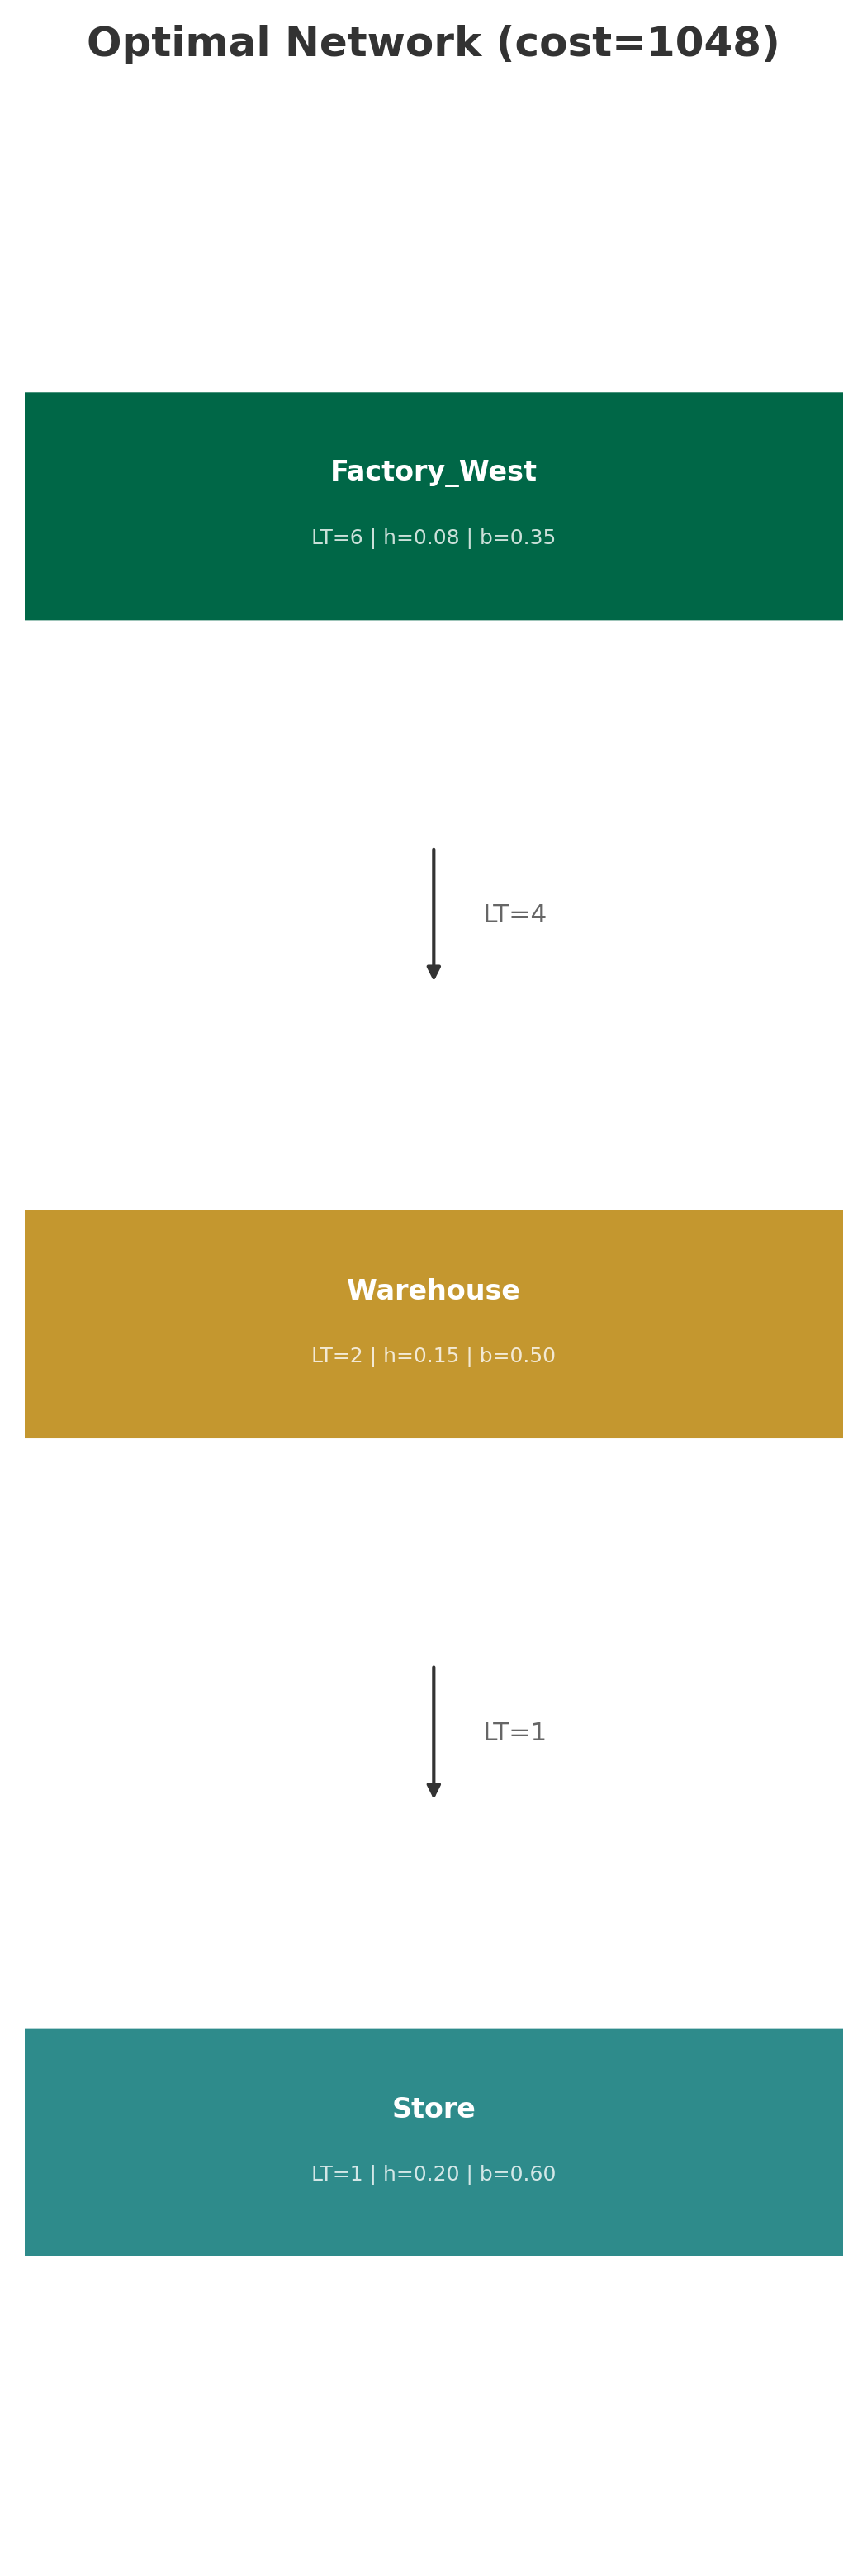

In [8]:
try:
    from deepbullwhip.optimize.network_design import (
        build_network_design_model, solve_network_design,
    )

    # Scenario: choosing between two factory locations
    candidates = {
        "Factory_East": EchelonConfig("Factory_East", 4, 0.10, 0.40),
        "Factory_West": EchelonConfig("Factory_West", 6, 0.08, 0.35),
        "Warehouse": EchelonConfig("Warehouse", 2, 0.15, 0.50),
        "Store": EchelonConfig("Store", 1, 0.20, 0.60),
    }
    candidate_edges = {
        ("Factory_East", "Warehouse"): EdgeConfig(lead_time=2, transport_cost=0.05),
        ("Factory_West", "Warehouse"): EdgeConfig(lead_time=4, transport_cost=0.03),
        ("Warehouse", "Store"): EdgeConfig(lead_time=1, transport_cost=0.02),
    }
    # Factory_East is closer (lower lead time) but more expensive to open
    fixed_costs = {
        "Factory_East": 1000,  # expensive but fast
        "Factory_West": 600,   # cheap but slow
        "Warehouse": 400,
        "Store": 0,            # must be open (demand node)
    }
    demand_volume = {"Store": 100.0}

    model = build_network_design_model(
        candidates, candidate_edges, fixed_costs, demand_volume,
    )

    print("Network design model built!")
    print(f"  Candidate nodes: {list(candidates.keys())}")
    print(f"  Candidate edges: {len(candidate_edges)}")
    print(f"  Demand: Store needs {demand_volume['Store']} units/period")
    print(f"  Decision: open Factory_East (fast, $1000) or Factory_West (slow, $600)?")

    # Try to solve
    try:
        result = solve_network_design(model, solver="glpk")
        print(f"\nOPTIMAL NETWORK:")
        print(f"  Open facilities: {result.open_nodes}")
        print(f"  Total cost: {result.total_cost:.1f}")
        print(f"  Active edges: {list(result.optimal_graph.edges.keys())}")

        # Visualize the optimal network
        fig = render_graph(
            result.optimal_graph, theme="kfupm",
            title=f"Optimal Network (cost={result.total_cost:.0f})",
        )
        plt.show()
    except Exception as e:
        print(f"\nSolver not available: {e}")
        print("Install a solver: conda install -c conda-forge glpk")

except ImportError as e:
    print(f"Pyomo not installed: {e}")
    print("Install with: pip install deepbullwhip[optimize]")

## 5. Putting It All Together: Optimize → Simulate → Visualize

A typical workflow combines optimization with simulation and visualization:

Optimal service levels:
  Retailer: 0.80
  Wholesaler: 0.85
  Distributor: 0.90
  Factory: 0.80

Simulation results with optimized policy:
  Retailer      BW=3.27  FR=85%  Cost=116
  Wholesaler    BW=6.17  FR=75%  Cost=189
  Distributor   BW=9.44  FR=77%  Cost=299
  Factory       BW=1.41  FR=73%  Cost=420


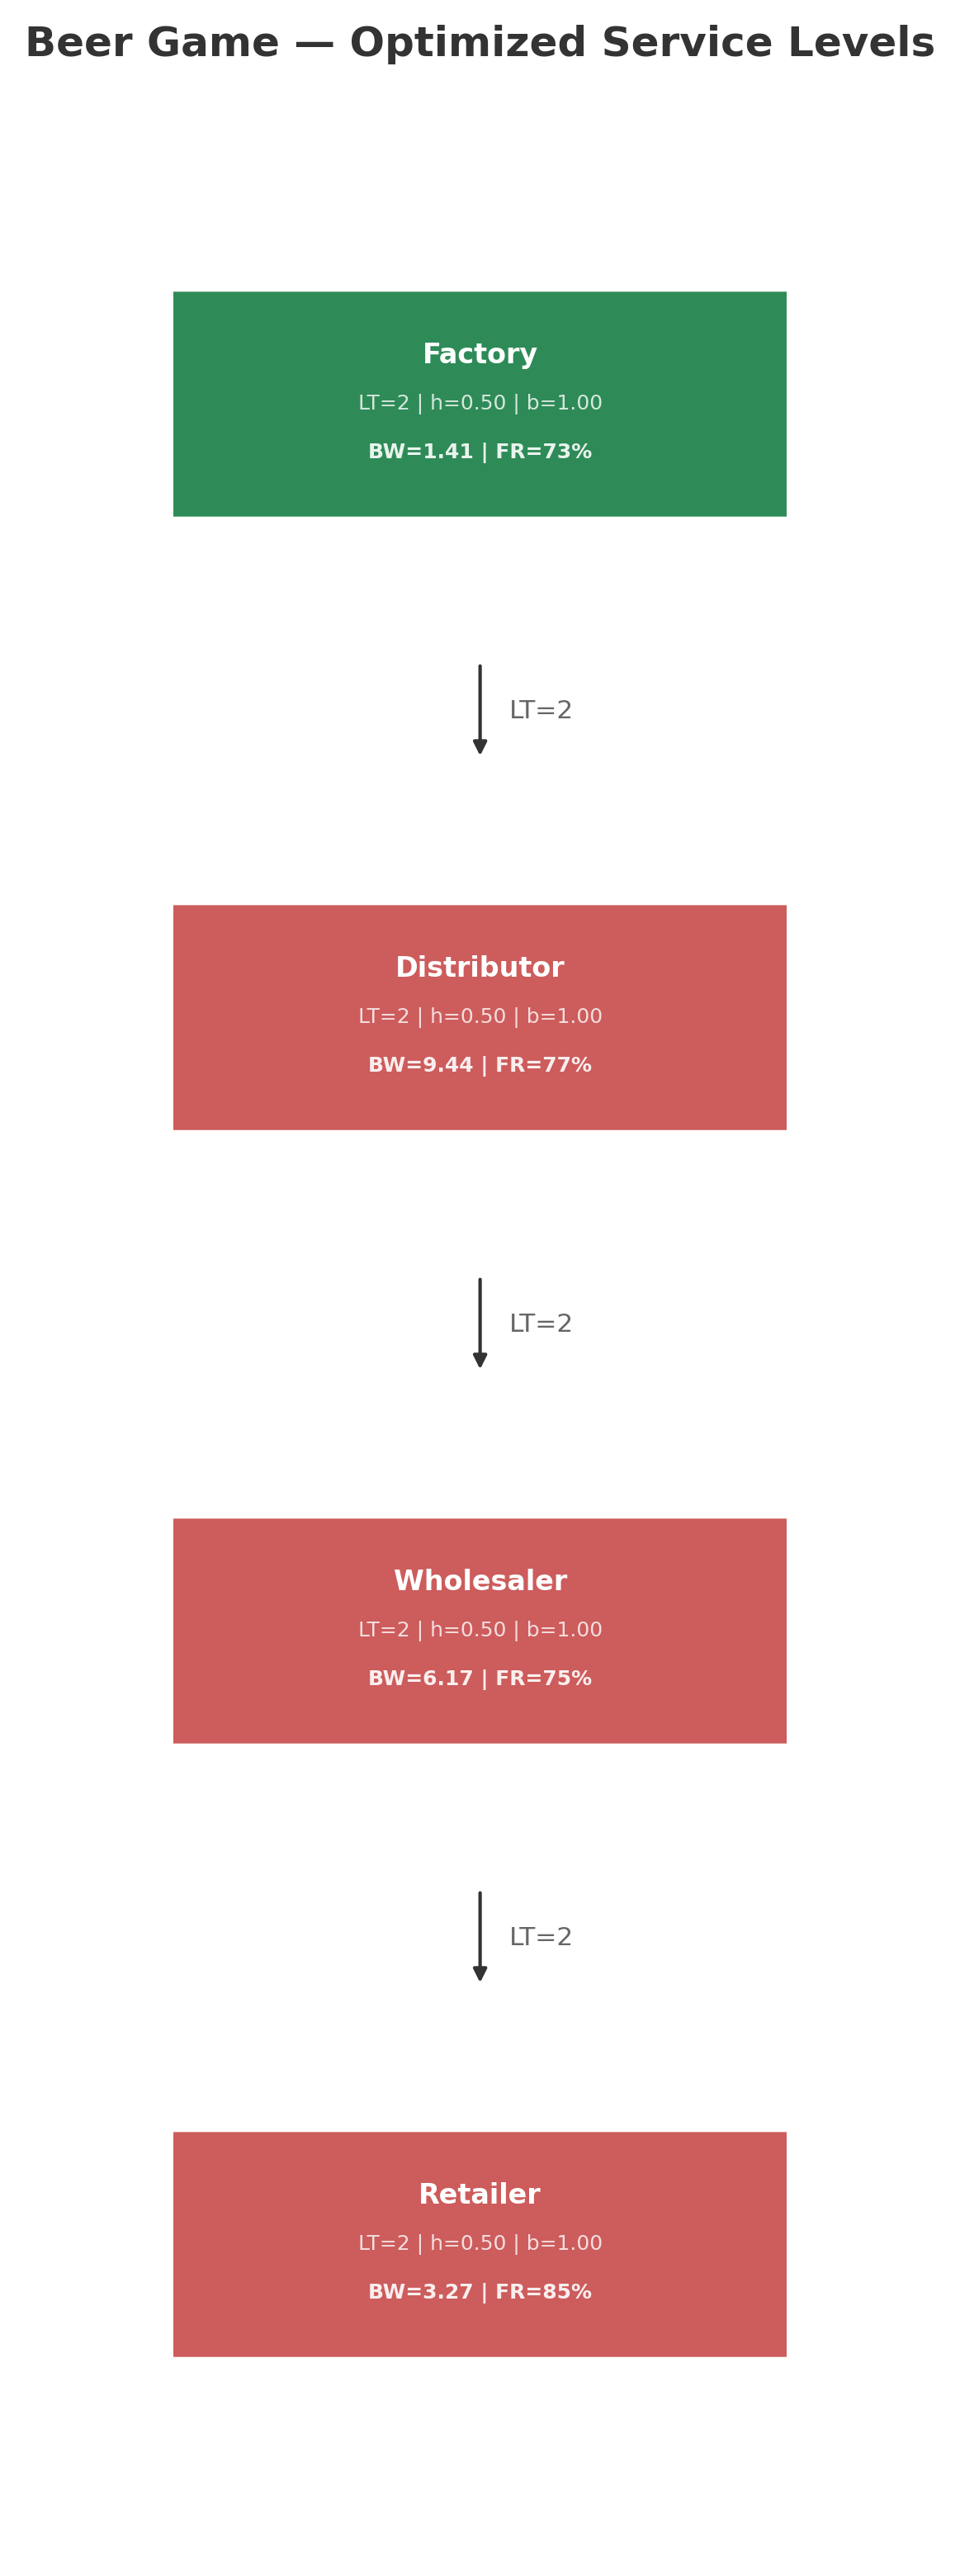

In [9]:
# Step 1: Define the network
graph = from_serial(beer_game_config())

# Step 2: Generate demand scenarios
rng = np.random.default_rng(42)
scenarios = np.maximum(rng.normal(10.0, 2.0, (15, 52)), 0)

# Step 3: Find optimal service levels
optimal = tune_service_levels(graph, scenarios, objective="weighted", grid_points=5)
print("Optimal service levels:")
for name, sl in optimal.parameters.items():
    print(f"  {name}: {sl:.2f}")

# Step 4: Simulate with optimal policy
chain = NetworkSupplyChain(
    graph,
    policies={
        name: OrderUpToPolicy(lead_time=cfg.lead_time, service_level=optimal.parameters[name])
        for name, cfg in graph.nodes.items()
    },
)

demand = scenarios[0]  # use first scenario for visualization
result = chain.simulate(
    demand={"Retailer": demand},
    forecasts_mean={"Retailer": np.full(52, demand.mean())},
    forecasts_std={"Retailer": np.full(52, demand.std())},
)

# Step 5: Visualize the optimized chain
print(f"\nSimulation results with optimized policy:")
for name, er in result.node_results.items():
    print(f"  {name:12s}  BW={er.bullwhip_ratio:.2f}  FR={er.fill_rate:.0%}  Cost={er.total_cost:,.0f}")

fig = render_graph(
    graph, sim_result=result, theme="kfupm",
    title="Beer Game — Optimized Service Levels",
)
plt.show()

## Summary

| Optimization Type | Function | Solver Needed? | Use Case |
|-------------------|----------|----------------|----------|
| **Service level tuning** | `tune_service_levels()` | No | Find optimal target fill rates per echelon |
| **Smoothing factor tuning** | `tune_smoothing_factors()` | No | Find optimal order smoothing parameters |
| **Inventory optimization** | `build_inventory_model()` + `solve_model()` | Yes (GLPK/CBC) | Find optimal base-stock levels via stochastic LP |
| **Network design** | `build_network_design_model()` + `solve_network_design()` | Yes (GLPK/CBC) | Decide which facilities to open via MIP |

### Key Takeaways

1. **Start with policy tuning** — it's fast (no solver needed) and often sufficient
2. **Use multiple demand scenarios** — more scenarios = more robust solutions, but slower
3. **Compare objectives** — cost-optimal and bullwhip-optimal configurations are usually different
4. **Smoothing helps** — SmoothingOUT with tuned `alpha_s` often outperforms standard OUT
5. **Visualize results** — use `render_graph(graph, sim_result=...)` to see where bullwhip amplifies

---

See also:
- [`04_network_viz_tutorial.ipynb`](04_network_viz_tutorial.ipynb) — network topologies, JSON schema, multi-backend rendering
- [`06_benchmark_policies.ipynb`](06_benchmark_policies.ipynb) — systematic policy comparison